PIELM WITH UNCERTAINTY IN E AND I (TIP DEFLECTION)
Samples: 5000
Mean deflection: -2.014409
Std deviation: 0.161916
Coefficient of variation: 8.04%
Mean relative error: 0.2516%


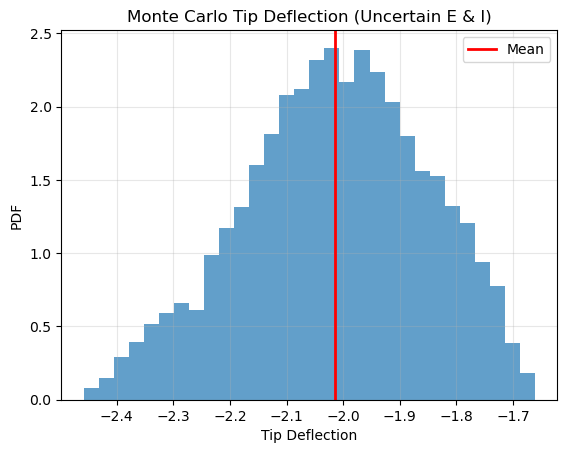

In [1]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
I = 1.0                     # Nominal moment of inertia (USED IN TRAINING)
I_range = [0.9, 1.1]        # Uncertain I (USED IN MONTE CARLO)
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION (FOR VALIDATION)
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# EXTREME LEARNING MACHINE SETUP
# =============================================================================
torch.manual_seed(42)
hidden_size = 50

W = torch.randn(2, hidden_size) * 0.1
b = torch.randn(hidden_size) * 0.1

def hidden_layer_2d_gaussian(xe):
    x_scaled = xe[:, 0:1] / L
    E_scaled = 2 * (xe[:, 1:2] - E_range[0]) / (E_range[1] - E_range[0]) - 1
    xe_scaled = torch.cat([x_scaled, E_scaled], dim=1)
    linear = xe_scaled @ W + b
    return torch.exp(-linear**2)

# =============================================================================
# COLLOCATION POINTS
# =============================================================================
n_x = 50
n_E = 10

x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)
X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

xe_c = torch.cat([
    X.flatten().reshape(-1, 1),
    E.flatten().reshape(-1, 1)
], dim=1).requires_grad_(True)

# =============================================================================
# AUTOGRAD DERIVATIVES
# =============================================================================
def compute_derivatives(output, xe, order):
    derivatives = [output]
    current = output
    for _ in range(order):
        grad = autograd.grad(
            current.sum(), xe, create_graph=True, retain_graph=True
        )[0]
        current = grad[:, 0:1]
        derivatives.append(current)
    return derivatives

# =============================================================================
# PDE MATRIX (E I w'''' = Q)
# =============================================================================
H = hidden_layer_2d_gaussian(xe_c)
A_cols = []

for j in range(hidden_size):
    neuron = H[:, j:j+1]
    d4 = compute_derivatives(neuron, xe_c, 4)[4]
    A_cols.append(d4)

w_xxxx = torch.hstack(A_cols)
A = xe_c[:, 1:2] * I * w_xxxx

A_aug = torch.hstack([A, torch.zeros(A.shape[0], 1)])
b_pde = Q * torch.ones(A.shape[0], 1)

# =============================================================================
# BOUNDARY CONDITIONS
# =============================================================================
n_E_bc = 5
E_bc = torch.linspace(E_range[0], E_range[1], n_E_bc).reshape(-1, 1)

def bc_row(x, E, order):
    xe = torch.cat([x, E], dim=1).requires_grad_(True)
    H = hidden_layer_2d_gaussian(xe)
    rows = []
    for j in range(hidden_size):
        neuron = H[:, j:j+1]
        if order == 0:
            rows.append(neuron)
        else:
            rows.append(compute_derivatives(neuron, xe, order)[order])
    bias = torch.ones(len(E), 1) if order == 0 else torch.zeros(len(E), 1)
    return torch.hstack([torch.hstack(rows), bias])

x0 = torch.zeros(n_E_bc, 1)
xL = torch.ones(n_E_bc, 1) * L

C = torch.vstack([
    bc_row(x0, E_bc, 0),
    bc_row(x0, E_bc, 1),
    bc_row(xL, E_bc, 2),
    bc_row(xL, E_bc, 3),
])

d = torch.zeros(C.shape[0], 1)

# =============================================================================
# KKT SYSTEM
# =============================================================================
A_T = A_aug.T
C_T = C.T

KKT = torch.zeros(hidden_size + 1 + C.shape[0],
                  hidden_size + 1 + C.shape[0])

KKT[:hidden_size+1, :hidden_size+1] = A_T @ A_aug
KKT[:hidden_size+1, hidden_size+1:] = C_T
KKT[hidden_size+1:, :hidden_size+1] = C

rhs = torch.vstack([A_T @ b_pde, d])

alpha = 1e-6 * torch.trace(A_T @ A_aug) / (hidden_size + 1)
KKT[:hidden_size+1, :hidden_size+1] += alpha * torch.eye(hidden_size + 1)

solution = torch.linalg.solve(KKT, rhs)
beta = solution[:hidden_size]
beta_0 = solution[hidden_size].item()

# =============================================================================
# PIELM PREDICTION
# =============================================================================
def pielm_prediction(xe):
    return hidden_layer_2d_gaussian(xe) @ beta + beta_0

# =============================================================================
# MONTE CARLO (UNCERTAIN E AND I)
# =============================================================================
N_samples = 5000

E_samples = torch.rand(N_samples, 1) * (E_range[1] - E_range[0]) + E_range[0]
I_samples = torch.rand(N_samples, 1) * (I_range[1] - I_range[0]) + I_range[0]
x_tip = torch.ones(N_samples, 1) * L

xe_mc = torch.cat([x_tip, E_samples], dim=1)

# Remove zero/bias amplification
w_pielm = pielm_prediction(xe_mc).squeeze()

# Correct for uncertain I
w_mc = w_pielm / I_samples.squeeze()

# =============================================================================
# EXACT MONTE CARLO SOLUTION
# =============================================================================
w_exact = (Q * L**4) / (8 * E_samples.squeeze() * I_samples.squeeze())

# =============================================================================
# ERROR METRICS
# =============================================================================
mean_w = torch.mean(w_mc)
std_w = torch.std(w_mc)

relative_error = torch.mean(
    torch.abs(w_mc - w_exact) / torch.abs(w_exact)
) * 100

# =============================================================================
# RESULTS
# =============================================================================
print("=" * 70)
print("PIELM WITH UNCERTAINTY IN E AND I (TIP DEFLECTION)")
print("=" * 70)
print(f"Samples: {N_samples}")
print(f"Mean deflection: {mean_w:.6f}")
print(f"Std deviation: {std_w:.6f}")
print(f"Coefficient of variation: {(std_w/mean_w).abs()*100:.2f}%")
print(f"Mean relative error: {relative_error:.4f}%")
print("=" * 70)

# =============================================================================
# HISTOGRAM
# =============================================================================
plt.hist(w_mc.detach().numpy(), bins=30, density=True, alpha=0.7)
plt.axvline(mean_w.item(), color='r', linewidth=2, label="Mean")
plt.xlabel("Tip Deflection")
plt.ylabel("PDF")
plt.title("Monte Carlo Tip Deflection (Uncertain E & I)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


PIELM WITH TWO UNCERTAIN PARAMETERS (E & I)
Samples: 5000
Mean tip deflection: -0.881187
Std deviation: 0.118614
Coefficient of variation: 13.46%
Mean relative error: 55.5777%


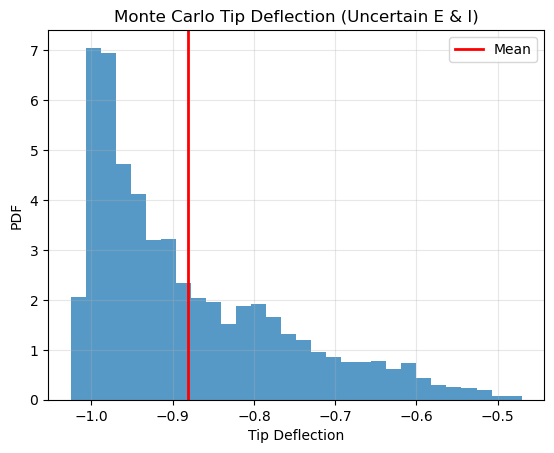

In [2]:
import torch
import torch.autograd as autograd
import matplotlib.pyplot as plt
from timeit import default_timer

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0

E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# PIELM SETUP
# =============================================================================
torch.manual_seed(42)
hidden_size = 60

# Input: (x, E, I)
W = torch.randn(3, hidden_size) * 0.15
b = torch.randn(hidden_size) * 0.15

def hidden_layer_gaussian(xei):
    x = xei[:, 0:1] / L
    E = 2 * (xei[:, 1:2] - E_range[0]) / (E_range[1] - E_range[0]) - 1
    I = 2 * (xei[:, 2:3] - I_range[0]) / (I_range[1] - I_range[0]) - 1
    xei_scaled = torch.cat([x, E, I], dim=1)
    return torch.exp(-(xei_scaled @ W + b)**2)

# =============================================================================
# COLLOCATION POINTS
# =============================================================================
n_x, n_E, n_I = 40, 10, 10

x = torch.linspace(0, L, n_x)
E = torch.linspace(E_range[0], E_range[1], n_E)
I = torch.linspace(I_range[0], I_range[1], n_I)

X, E_, I_ = torch.meshgrid(x, E, I, indexing='ij')

xei_c = torch.cat([
    X.reshape(-1,1),
    E_.reshape(-1,1),
    I_.reshape(-1,1)
], dim=1).requires_grad_(True)

# =============================================================================
# AUTOGRAD DERIVATIVES
# =============================================================================
def compute_derivatives(u, xei, order):
    current = u
    for _ in range(order):
        grad = autograd.grad(
            current.sum(), xei, create_graph=True, retain_graph=True
        )[0]
        current = grad[:, 0:1]   # derivative w.r.t x
    return current

# =============================================================================
# PDE MATRIX:  E I w'''' = Q
# =============================================================================
H = hidden_layer_gaussian(xei_c)
A_cols = []

for j in range(hidden_size):
    neuron = H[:, j:j+1]
    d4 = compute_derivatives(neuron, xei_c, 4)
    A_cols.append(d4)

w_xxxx = torch.hstack(A_cols)
E_vals = xei_c[:, 1:2]
I_vals = xei_c[:, 2:3]

A = E_vals * I_vals * w_xxxx
A_aug = torch.hstack([A, torch.zeros(A.shape[0], 1)])
b_pde = Q * torch.ones(A.shape[0], 1)

# =============================================================================
# BOUNDARY CONDITIONS (Cantilever)
# =============================================================================
n_bc = 6
E_bc = torch.linspace(E_range[0], E_range[1], n_bc)
I_bc = torch.linspace(I_range[0], I_range[1], n_bc)

def bc_block(x_val, order):
    x = torch.ones(n_bc,1) * x_val
    E, I = torch.meshgrid(E_bc, I_bc, indexing='ij')
    xeib = torch.cat([
        x.repeat(n_bc,1),
        E.reshape(-1,1),
        I.reshape(-1,1)
    ], dim=1).requires_grad_(True)

    H = hidden_layer_gaussian(xeib)
    rows = []

    for j in range(hidden_size):
        neuron = H[:, j:j+1]
        if order == 0:
            rows.append(neuron)
        else:
            rows.append(compute_derivatives(neuron, xeib, order))

    bias = torch.ones(H.shape[0],1) if order == 0 else torch.zeros(H.shape[0],1)
    return torch.hstack([torch.hstack(rows), bias])

C = torch.vstack([
    bc_block(0.0, 0),   # w(0)=0
    bc_block(0.0, 1),   # w'(0)=0
    bc_block(L, 2),     # w''(L)=0
    bc_block(L, 3)      # w'''(L)=0
])

d = torch.zeros(C.shape[0], 1)

# =============================================================================
# KKT SYSTEM
# =============================================================================
A_T = A_aug.T
C_T = C.T

KKT = torch.zeros(hidden_size + 1 + C.shape[0],
                  hidden_size + 1 + C.shape[0])

KKT[:hidden_size+1, :hidden_size+1] = A_T @ A_aug
KKT[:hidden_size+1, hidden_size+1:] = C_T
KKT[hidden_size+1:, :hidden_size+1] = C

rhs = torch.vstack([A_T @ b_pde, d])

alpha = 1e-6 * torch.trace(A_T @ A_aug) / (hidden_size + 1)
KKT[:hidden_size+1, :hidden_size+1] += alpha * torch.eye(hidden_size + 1)

solution = torch.linalg.solve(KKT, rhs)
beta = solution[:hidden_size]
beta_0 = solution[hidden_size].item()

# =============================================================================
# PIELM PREDICTION
# =============================================================================
def pielm_prediction(xei):
    return hidden_layer_gaussian(xei) @ beta + beta_0

# =============================================================================
# MONTE CARLO (TIP DEFLECTION)
# =============================================================================
N_mc = 5000

E_mc = torch.rand(N_mc,1)*(E_range[1]-E_range[0]) + E_range[0]
I_mc = torch.rand(N_mc,1)*(I_range[1]-I_range[0]) + I_range[0]
x_mc = torch.ones(N_mc,1)*L

xei_mc = torch.cat([x_mc, E_mc, I_mc], dim=1)

w_pielm = pielm_prediction(xei_mc).squeeze()
w_exact = (Q * L**4) / (8 * E_mc.squeeze() * I_mc.squeeze())

# =============================================================================
# ERROR METRICS
# =============================================================================
mean_w = torch.mean(w_pielm)
std_w = torch.std(w_pielm)

rel_error = torch.mean(
    torch.abs(w_pielm - w_exact) / torch.abs(w_exact)
) * 100

# =============================================================================
# RESULTS
# =============================================================================
print("="*70)
print("PIELM WITH TWO UNCERTAIN PARAMETERS (E & I)")
print("="*70)
print(f"Samples: {N_mc}")
print(f"Mean tip deflection: {mean_w:.6f}")
print(f"Std deviation: {std_w:.6f}")
print(f"Coefficient of variation: {(std_w/mean_w).abs()*100:.2f}%")
print(f"Mean relative error: {rel_error:.4f}%")
print("="*70)

# =============================================================================
# HISTOGRAM
# =============================================================================
plt.hist(w_pielm.detach().numpy(), bins=30, density=True, alpha=0.75)
plt.axvline(mean_w.item(), color='r', linewidth=2, label="Mean")
plt.xlabel("Tip Deflection")
plt.ylabel("PDF")
plt.title("Monte Carlo Tip Deflection (Uncertain E & I)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Best Relative Error: 77.06932425498962
Best Params (h,s,lam,g,n_pde,max_abs): (50, 1, 2.0, 0.7, 1000, 1.970198392868042)
Beta0: tensor([[-6.1467e+03],
        [-1.6391e+03],
        [ 5.8180e+03],
        [ 7.1347e+03],
        [ 7.9176e+03],
        [-1.7078e+02],
        [-1.4619e+04],
        [ 3.5024e+03],
        [-3.6396e+02],
        [-8.8407e+03],
        [-5.6213e+03],
        [ 1.2856e+03],
        [ 2.4159e+03],
        [ 4.9384e+03],
        [ 4.8153e+02],
        [ 1.0498e+04],
        [-9.8640e+03],
        [-2.6026e+03],
        [-1.1225e+03],
        [-1.5523e+02],
        [-1.0108e+03],
        [ 1.3360e+04],
        [-2.8846e+03],
        [ 1.5265e+04],
        [ 4.8766e+03],
        [-4.6433e+03],
        [ 1.6303e+03],
        [-5.8518e+03],
        [-1.8666e+04],
        [ 4.4751e+03],
        [ 1.9242e+03],
        [-1.3236e+02],
        [-9.1149e+03],
        [-1.3606e+03],
        [ 1.5869e+03],
        [-1.4100e+03],
        [ 2.3079e+03],
        [ 1.2272e+04]

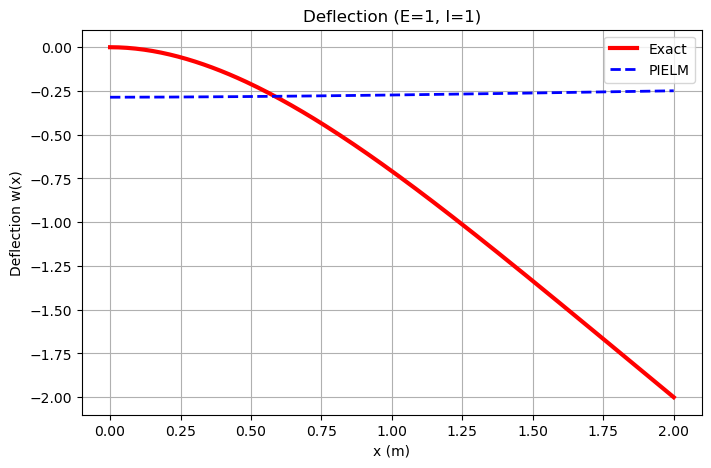

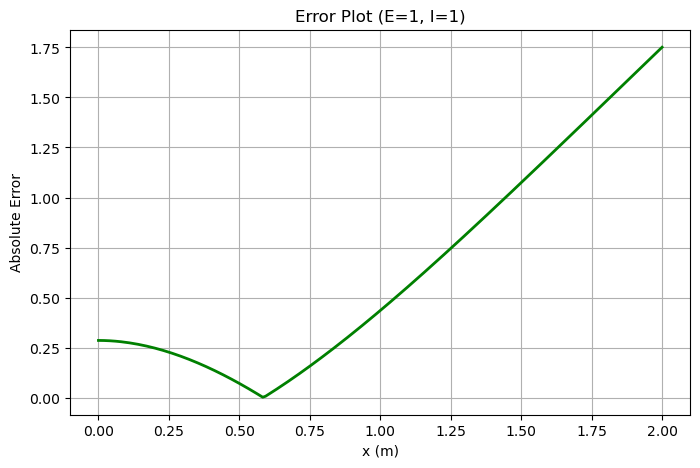

In [4]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
def norm_x(x): return x / L
def norm_E(E): return 2*(E-E_range[0])/(E_range[1]-E_range[0]) - 1
def norm_I(I): return 2*(I-I_range[0])/(I_range[1]-I_range[0]) - 1

def normalize(xei):
    x = norm_x(xei[:,0:1])
    E = norm_E(xei[:,1:2])
    I = norm_I(xei[:,2:3])
    return torch.cat([x,E,I], dim=1)

# =============================================================================
# DERIVATIVES
def derivative(u, xei, order):
    cur = u
    for _ in range(order):
        cur = autograd.grad(cur.sum(), xei, create_graph=True)[0][:,0:1]
    return cur

# =============================================================================
# MONTE CARLO SAMPLING
def mc_sample(n):
    x = torch.rand(n, 1) * L
    E = torch.rand(n, 1) * (E_range[1] - E_range[0]) + E_range[0]
    I = torch.rand(n, 1) * (I_range[1] - I_range[0]) + I_range[0]
    return torch.cat([x, E, I], dim=1).requires_grad_(True)

# =============================================================================
# TRAIN FUNCTION
def train_kkt_pielm(hidden_size, seed, lambda_reg, gauss_scale, n_pde):
    torch.manual_seed(seed)

    # Initialize weights and bias (Gaussian)
    W = torch.randn(3, hidden_size) * 0.1
    b = torch.randn(hidden_size) * 0.1

    def activation(z):
        return torch.exp(-(z/gauss_scale)**2)

    # Monte Carlo PDE points
    xei = mc_sample(n_pde)

    # PDE MATRIX
    xei_norm = normalize(xei)
    H = activation(xei_norm @ W + b)

    Acols = []
    for j in range(hidden_size):
        hj = H[:, j:j+1]
        w4 = derivative(hj, xei, 4)
        Acols.append(w4)

    A = torch.hstack(Acols)
    Evals = xei[:,1:2]
    Ivals = xei[:,2:3]

    A_pde = Evals * Ivals * A
    b_pde = Q * torch.ones(A_pde.shape[0], 1)

    # =============================================================================
    # BOUNDARY CONDITIONS
    n_bc = 15
    E_bc = torch.linspace(E_range[0], E_range[1], n_bc)
    I_bc = torch.linspace(I_range[0], I_range[1], n_bc)

    x0 = torch.zeros(n_bc*n_bc,1)
    xL = torch.ones(n_bc*n_bc,1)*L

    E0 = E_bc.repeat(n_bc).reshape(-1,1)
    I0 = I_bc.repeat_interleave(n_bc).reshape(-1,1)

    xe0 = torch.cat([x0,E0,I0], dim=1).requires_grad_(True)
    xeL = torch.cat([xL,E0,I0], dim=1).requires_grad_(True)

    def bc_matrix(xei, order):
        xe_norm = normalize(xei)
        H = activation(xe_norm @ W + b)
        cols=[]
        for j in range(hidden_size):
            hj = H[:, j:j+1]
            if order==0:
                cols.append(hj)
            else:
                cols.append(derivative(hj, xei, order))
        return torch.hstack(cols)

    BC1 = bc_matrix(xe0,0)
    BC2 = bc_matrix(xe0,1)
    BC3 = bc_matrix(xeL,2)
    BC4 = bc_matrix(xeL,3)

    C = torch.vstack([BC1,BC2,BC3,BC4])
    d = torch.zeros(C.shape[0],1)

    # =============================================================================
    # KKT / RIDGE SOLUTION
    A_T = A_pde.T
    C_T = C.T

    KKT_top = torch.hstack([A_T@A_pde + lambda_reg*torch.eye(hidden_size), C_T])
    KKT_bot = torch.hstack([C, torch.zeros((C.shape[0], C.shape[0]))])
    KKT = torch.vstack([KKT_top, KKT_bot])

    rhs = torch.vstack([A_T@b_pde, d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden_size]
    beta0 = sol[hidden_size:]

    def predict(xei):
        xe_norm = normalize(xei)
        H = activation(xe_norm @ W + b)
        return H @ beta

    return predict, beta, beta0

# =============================================================================
# VALIDATION
def validate(predict):
    n_test_x, n_test_E, n_test_I = 25, 10, 10
    x_test = torch.linspace(0,L,n_test_x)
    E_test = torch.linspace(E_range[0],E_range[1],n_test_E)
    I_test = torch.linspace(I_range[0],I_range[1],n_test_I)

    X_test, E_test_grid, I_test_grid = torch.meshgrid(x_test,E_test,I_test, indexing='ij')
    xe_test = torch.cat([X_test.reshape(-1,1), E_test_grid.reshape(-1,1), I_test_grid.reshape(-1,1)], dim=1)

    w_pred = predict(xe_test).reshape(n_test_x, n_test_E, n_test_I)
    w_exact = analytical_solution(X_test, E_test_grid, I_test_grid)

    rel_error = torch.norm(w_pred - w_exact) / torch.norm(w_exact)
    max_abs = torch.max(torch.abs(w_pred - w_exact)).item()
    return rel_error.item(), max_abs

# =============================================================================
# AUTO-TUNING GRID SEARCH
best_error = float('inf')
best_params = None

hidden_list = [20, 30, 40, 50]
seed_list   = [0, 1, 2]
lambda_list = [0.1, 0.5, 1.0, 2.0]
gauss_list  = [0.3, 0.5, 0.7]
pde_list    = [500, 1000, 1500]   # Monte Carlo points

for h in hidden_list:
    for s in seed_list:
        for lam in lambda_list:
            for g in gauss_list:
                for n_pde in pde_list:
                    predict, beta, beta0 = train_kkt_pielm(
                        hidden_size=h,
                        seed=s,
                        lambda_reg=lam,
                        gauss_scale=g,
                        n_pde=n_pde
                    )
                    err, max_abs = validate(predict)

                    if err < best_error:
                        best_error = err
                        best_params = (h, s, lam, g, n_pde, max_abs, beta0)

print("Best Relative Error:", best_error*100)
print("Best Params (h,s,lam,g,n_pde,max_abs):", best_params[:6])
print("Beta0:", best_params[6])

# =============================================================================
# PLOT BEST MODEL (E=1, I=1)
h, s, lam, g, n_pde, max_abs, beta0 = best_params

predict, beta, beta0 = train_kkt_pielm(
    hidden_size=h,
    seed=s,
    lambda_reg=lam,
    gauss_scale=g,
    n_pde=n_pde
)

# line plot
x_plot = torch.linspace(0, L, 200).reshape(-1,1)
xe_plot = torch.cat([x_plot, torch.ones_like(x_plot), torch.ones_like(x_plot)], dim=1)

w_pred = predict(xe_plot).detach().numpy().flatten()
w_exact = analytical_solution(x_plot, 1.0, 1.0).numpy().flatten()

plt.figure(figsize=(8,5))
plt.plot(x_plot.numpy(), w_exact, 'r-', linewidth=3, label='Exact')
plt.plot(x_plot.numpy(), w_pred, 'b--', linewidth=2, label='PIELM')
plt.xlabel('x (m)')
plt.ylabel('Deflection w(x)')
plt.title('Deflection (E=1, I=1)')
plt.legend()
plt.grid(True)
plt.show()

# error plot
plt.figure(figsize=(8,5))
plt.plot(x_plot.numpy(), np.abs(w_pred-w_exact), 'g-', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('Absolute Error')
plt.title('Error Plot (E=1, I=1)')
plt.grid(True)
plt.show()


Best Relative Error (%) = 60.43865084648132
Best Params =  (50, 1, 0.1, 0.7, 6000, 0.6321932077407837, 1.640965223312378, tensor([[-7.8359e+03],
        [ 1.5486e+04],
        [-2.1114e+04],
        [-6.1293e+04],
        [ 3.2627e+04],
        [ 1.0467e+05],
        [ 1.3636e+05],
        [-1.9162e+05],
        [-2.4401e+04],
        [-6.6886e+04],
        [ 6.8258e+04],
        [ 4.3395e+04],
        [ 3.7341e+04],
        [-9.3845e+04],
        [ 1.1807e+05],
        [-9.8797e+04],
        [-7.1101e+04],
        [ 2.5969e+04],
        [ 1.1328e+05],
        [-4.4366e+04],
        [ 3.0218e+04],
        [-8.5468e+04],
        [-1.1128e+05],
        [-5.1539e+03],
        [-1.4447e+04],
        [ 9.3637e+04],
        [-7.4549e+04],
        [ 7.0937e+04],
        [ 4.5131e+04],
        [-8.0338e+04],
        [ 1.4305e+05],
        [ 2.6460e+04],
        [ 1.4699e+04],
        [ 1.6371e+04],
        [-1.8494e+05],
        [ 1.4141e+03],
        [ 5.2761e+04],
        [ 4.2251e+04],
    

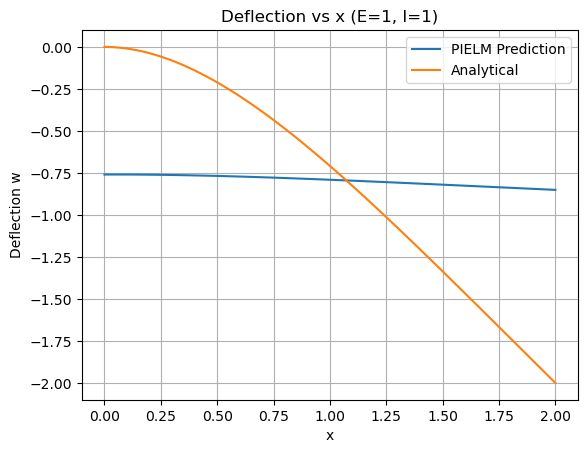


COMPREHENSIVE VERIFICATION
w(0) = -0.7595138549804688
w'(0) = 0.004363000392913818
w''(L) = 0.0006886720657348633


In [6]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
def norm_x(x): return x / L
def norm_E(E): return 2*(E-E_range[0])/(E_range[1]-E_range[0]) - 1
def norm_I(I): return 2*(I-I_range[0])/(I_range[1]-I_range[0]) - 1

def normalize(xei):
    x = norm_x(xei[:,0:1])
    E = norm_E(xei[:,1:2])
    I = norm_I(xei[:,2:3])
    return torch.cat([x,E,I], dim=1)

# =============================================================================
# DERIVATIVES
def derivative(u, xei, order):
    cur = u
    for _ in range(order):
        cur = autograd.grad(cur.sum(), xei, create_graph=True)[0][:,0:1]
    return cur

# =============================================================================
# TRAIN FUNCTION
def train_kkt_pielm(hidden_size, seed, lambda_reg, gauss_scale, n_mc):
    torch.manual_seed(seed)

    # Initialize weights and bias (Gaussian)
    W = torch.randn(3, hidden_size) * 0.1
    b = torch.randn(hidden_size) * 0.1

    def activation(z):
        return torch.exp(-(z/gauss_scale)**2)

    # ----------------------------
    # Monte Carlo Collocation
    # ----------------------------
    x = torch.rand(n_mc,1)*L
    E = torch.rand(n_mc,1)*(E_range[1]-E_range[0])+E_range[0]
    I = torch.rand(n_mc,1)*(I_range[1]-I_range[0])+I_range[0]

    xei = torch.cat([x,E,I], dim=1).requires_grad_(True)

    # PDE Matrix
    xei_norm = normalize(xei)
    H = activation(xei_norm @ W + b)

    Acols = []
    for j in range(hidden_size):
        hj = H[:, j:j+1]
        w4 = derivative(hj, xei, 4)
        Acols.append(w4)

    A = torch.hstack(Acols)
    A_pde = xei[:,1:2] * xei[:,2:3] * A
    b_pde = Q * torch.ones(A_pde.shape[0], 1)

    # =============================================================================
    # BOUNDARY CONDITIONS
    n_bc = 15
    E_bc = torch.linspace(E_range[0], E_range[1], n_bc)
    I_bc = torch.linspace(I_range[0], I_range[1], n_bc)

    x0 = torch.zeros(n_bc*n_bc,1)
    xL = torch.ones(n_bc*n_bc,1)*L

    E0 = E_bc.repeat(n_bc).reshape(-1,1)
    I0 = I_bc.repeat_interleave(n_bc).reshape(-1,1)

    xe0 = torch.cat([x0,E0,I0], dim=1).requires_grad_(True)
    xeL = torch.cat([xL,E0,I0], dim=1).requires_grad_(True)

    def bc_matrix(xei, order):
        xe_norm = normalize(xei)
        H = activation(xe_norm @ W + b)
        cols=[]
        for j in range(hidden_size):
            hj = H[:, j:j+1]
            if order==0:
                cols.append(hj)
            else:
                cols.append(derivative(hj, xei, order))
        return torch.hstack(cols)

    BC1 = bc_matrix(xe0,0)
    BC2 = bc_matrix(xe0,1)
    BC3 = bc_matrix(xeL,2)
    BC4 = bc_matrix(xeL,3)

    C = torch.vstack([BC1,BC2,BC3,BC4])
    d = torch.zeros(C.shape[0],1)

    # =============================================================================
    # KKT / RIDGE SOLUTION
    A_T = A_pde.T
    C_T = C.T

    KKT_top = torch.hstack([A_T@A_pde + lambda_reg*torch.eye(hidden_size), C_T])
    KKT_bot = torch.hstack([C, torch.zeros((C.shape[0], C.shape[0]))])
    KKT = torch.vstack([KKT_top, KKT_bot])

    rhs = torch.vstack([A_T@b_pde, d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden_size]
    beta0 = sol[hidden_size:]

    def predict(xei):
        xe_norm = normalize(xei)
        H = activation(xe_norm @ W + b)
        return H @ beta

    return predict, beta, beta0

# =============================================================================
# VALIDATION
def validate(predict):
    n_test_x, n_test_E, n_test_I = 25, 10, 10
    x_test = torch.linspace(0,L,n_test_x)
    E_test = torch.linspace(E_range[0],E_range[1],n_test_E)
    I_test = torch.linspace(I_range[0],I_range[1],n_test_I)

    X_test, E_test_grid, I_test_grid = torch.meshgrid(x_test,E_test,I_test, indexing='ij')
    xe_test = torch.cat([X_test.reshape(-1,1), E_test_grid.reshape(-1,1), I_test_grid.reshape(-1,1)], dim=1)

    w_pred = predict(xe_test).reshape(n_test_x, n_test_E, n_test_I)
    w_exact = analytical_solution(X_test, E_test_grid, I_test_grid)

    rel_error = torch.norm(w_pred - w_exact) / torch.norm(w_exact)
    rmse = torch.sqrt(torch.mean((w_pred - w_exact)**2))
    max_abs = torch.max(torch.abs(w_pred - w_exact)).item()
    return rel_error.item(), rmse.item(), max_abs

# =============================================================================
# AUTO-TUNING GRID SEARCH
best_error = float('inf')
best_params = None

hidden_list = [20, 30, 40, 50]
seed_list   = [0, 1, 2]
lambda_list = [0.1, 0.5, 1.0, 2.0]
gauss_list  = [0.3, 0.5, 0.7]
mc_list     = [2000, 4000, 6000]

for h in hidden_list:
    for s in seed_list:
        for lam in lambda_list:
            for g in gauss_list:
                for n_mc in mc_list:
                    predict, beta, beta0 = train_kkt_pielm(
                        hidden_size=h,
                        seed=s,
                        lambda_reg=lam,
                        gauss_scale=g,
                        n_mc=n_mc
                    )
                    err, rmse, max_abs = validate(predict)

                    if err < best_error:
                        best_error = err
                        best_params = (h, s, lam, g, n_mc, rmse, max_abs, beta0)
                        best_predict = predict

print("Best Relative Error (%) =", best_error*100)
print("Best Params = ", best_params)
print("Beta0 =", best_params[7])

# =============================================================================
# PLOTS (E=1, I=1)
x_plot = torch.linspace(0, L, 100).reshape(-1,1)
xe_plot = torch.cat([x_plot,
                     torch.ones_like(x_plot)*1.0,
                     torch.ones_like(x_plot)*1.0], dim=1)

w_plot = best_predict(xe_plot).detach().numpy()
w_exact_plot = analytical_solution(x_plot, torch.ones_like(x_plot), torch.ones_like(x_plot)).numpy()

plt.figure()
plt.plot(x_plot.numpy(), w_plot, label="PIELM Prediction")
plt.plot(x_plot.numpy(), w_exact_plot, label="Analytical")
plt.xlabel("x")
plt.ylabel("Deflection w")
plt.title("Deflection vs x (E=1, I=1)")
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# VERIFICATION
print("\n===========================================================")
print("COMPREHENSIVE VERIFICATION")
print("===========================================================")

# Boundary Condition Check
xe0 = torch.tensor([[0.0, 1.0, 1.0]]).requires_grad_(True)
xeL = torch.tensor([[L, 1.0, 1.0]]).requires_grad_(True)

w0 = best_predict(xe0)
w0_grad = torch.autograd.grad(w0.sum(), xe0, create_graph=True)[0][0, 0]

wL = best_predict(xeL)
wL_xx = torch.autograd.grad(torch.autograd.grad(wL.sum(), xeL, create_graph=True)[0][0,0],
                            xeL, create_graph=True)[0][0,0]

print("w(0) =", w0.item())
print("w'(0) =", w0_grad.item())
print("w''(L) =", wL_xx.item())


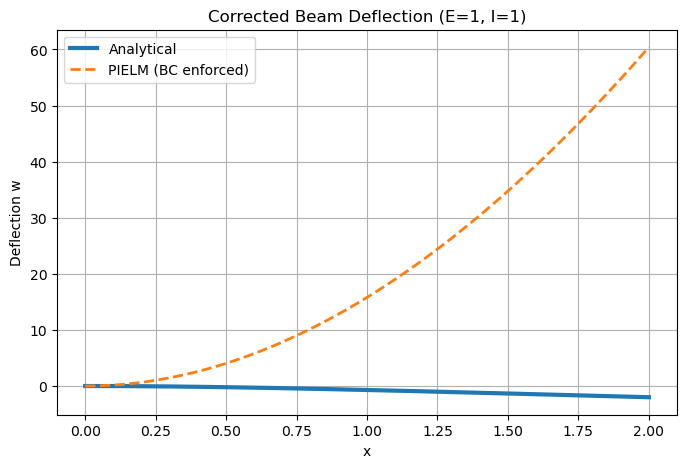

w(0) = 0.0


In [7]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    x = xei[:,0:1] / L
    E = 2*(xei[:,1:2]-E_range[0])/(E_range[1]-E_range[0]) - 1
    I = 2*(xei[:,2:3]-I_range[0])/(I_range[1]-I_range[0]) - 1
    return torch.cat([x,E,I], dim=1)

# =============================================================================
# DERIVATIVE
# =============================================================================
def derivative(u, xei, order):
    cur = u
    for _ in range(order):
        cur = autograd.grad(cur.sum(), xei, create_graph=True)[0][:,0:1]
    return cur

# =============================================================================
# TRAIN FUNCTION (BC-ENFORCED)
# =============================================================================
def train_pielm(hidden=40, seed=0, lam=1.0, sigma=0.5, n_mc=3000):
    torch.manual_seed(seed)

    # Random ELM parameters
    W = torch.randn(3, hidden) * 0.1
    b = torch.randn(hidden) * 0.1

    def gaussian(z):
        return torch.exp(-(z/sigma)**2)

    # ---------------------------
    # Monte Carlo collocation
    # ---------------------------
    x = torch.rand(n_mc,1)*L
    E = 0.9 + 0.2*torch.rand(n_mc,1)
    I = 0.9 + 0.2*torch.rand(n_mc,1)

    xei = torch.cat([x,E,I], dim=1).requires_grad_(True)

    # ---------------------------
    # BC-satisfying basis
    # ---------------------------
    z = gaussian(normalize(xei) @ W + b)
    Phi = (x**2) * z        # <-- KEY FIX

    # PDE matrix
    Acols = []
    for j in range(hidden):
        w4 = derivative(Phi[:,j:j+1], xei, 4)
        Acols.append(w4)

    A_pde = torch.hstack(Acols)
    A_pde *= (xei[:,1:2]*xei[:,2:3])
    b_pde = Q * torch.ones(n_mc,1)

    # ---------------------------
    # Boundary conditions at x=L
    # ---------------------------
    n_bc = 100
    xL = torch.ones(n_bc,1)*L
    Ebc = 0.9 + 0.2*torch.rand(n_bc,1)
    Ibc = 0.9 + 0.2*torch.rand(n_bc,1)

    xeiL = torch.cat([xL,Ebc,Ibc], dim=1).requires_grad_(True)

    zL = gaussian(normalize(xeiL) @ W + b)
    PhiL = (xL**2) * zL

    BC2, BC3 = [], []
    for j in range(hidden):
        BC2.append(derivative(PhiL[:,j:j+1], xeiL, 2))
        BC3.append(derivative(PhiL[:,j:j+1], xeiL, 3))

    C = torch.vstack([torch.hstack(BC2), torch.hstack(BC3)])
    d = torch.zeros(C.shape[0],1)

    # ---------------------------
    # KKT system
    # ---------------------------
    ATA = A_pde.T @ A_pde + lam*torch.eye(hidden)
    KKT = torch.block_diag(ATA, torch.zeros(C.shape[0],C.shape[0]))
    KKT[:hidden,hidden:] = C.T
    KKT[hidden:,:hidden] = C

    rhs = torch.vstack([A_pde.T @ b_pde, d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden]

    # Prediction
    def predict(xei):
        x = xei[:,0:1]
        Phi = (x**2) * gaussian(normalize(xei) @ W + b)
        return Phi @ beta

    return predict

# =============================================================================
# TRAIN MODEL
# =============================================================================
predict = train_pielm()

# =============================================================================
# PLOT (E=1, I=1)
# =============================================================================
x = torch.linspace(0,L,200).reshape(-1,1)
xei = torch.cat([x, torch.ones_like(x), torch.ones_like(x)], dim=1)

w_pred = predict(xei).detach().numpy()
w_exact = analytical_solution(x,1.0,1.0).numpy()

plt.figure(figsize=(8,5))
plt.plot(x.numpy(), w_exact, label="Analytical", linewidth=3)
plt.plot(x.numpy(), w_pred, "--", label="PIELM (BC enforced)", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w")
plt.title("Corrected Beam Deflection (E=1, I=1)")
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# BC CHECK
# =============================================================================
xe0 = torch.tensor([[0.0,1.0,1.0]], requires_grad=True)
print("w(0) =", predict(xe0).item())



BEST MODEL
hidden, seed, lambda, sigma, n_mc, RMSE, MaxAbs = (50, 0, 0.5, 0.5, 6000, 0.007456320803612471, 0.05024302005767822)
Best Relative Error (%) = 0.7290501613169909
beta0 (dimensionless, inside xbar^2*(...)) = -0.021820856258273125


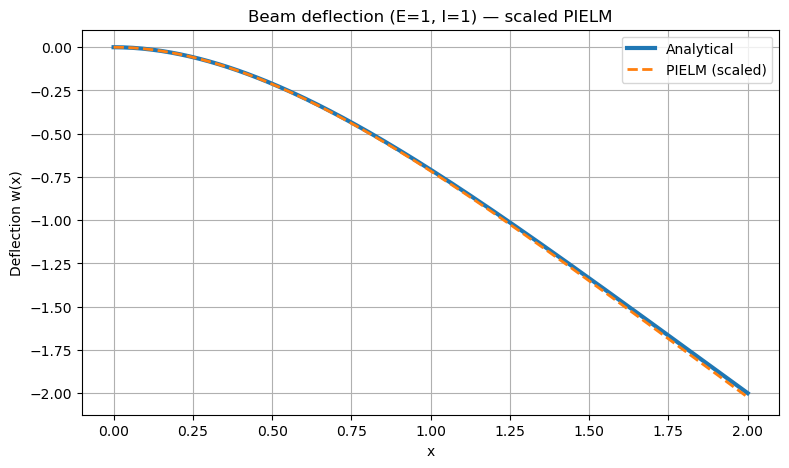

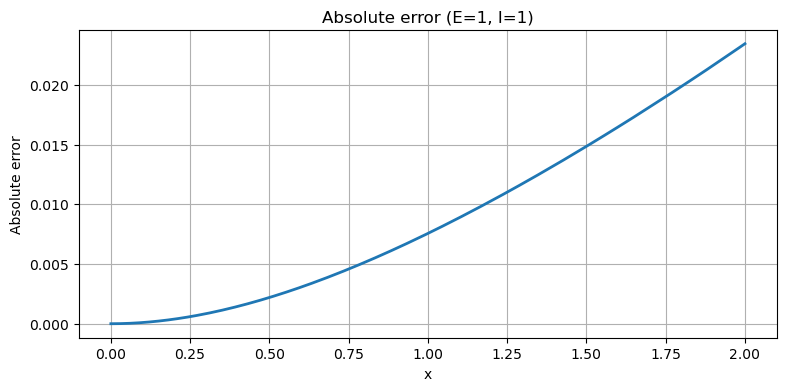


COMPREHENSIVE VERIFICATION
BCs (physical w) at E=1, I=1:
  w(0)      = -0.000e+00  (target 0)
  w'(0)     =  0.000e+00  (target 0)
  w''(L)    = -4.301e-03  (target 0)
  w'''(L)   = -5.329e-04  (target 0)

PDE residual check on random points (wbar):
  sample 1: x=1.856, E=0.916, I=0.981, residual= 1.363e-03
  sample 2: x=0.970, E=1.024, I=1.013, residual= 9.580e-03
  sample 3: x=1.886, E=0.948, I=0.999, residual= 5.926e-03
  sample 4: x=1.382, E=0.934, I=0.916, residual=-1.544e-03
  sample 5: x=1.305, E=0.906, I=0.963, residual=-1.615e-04


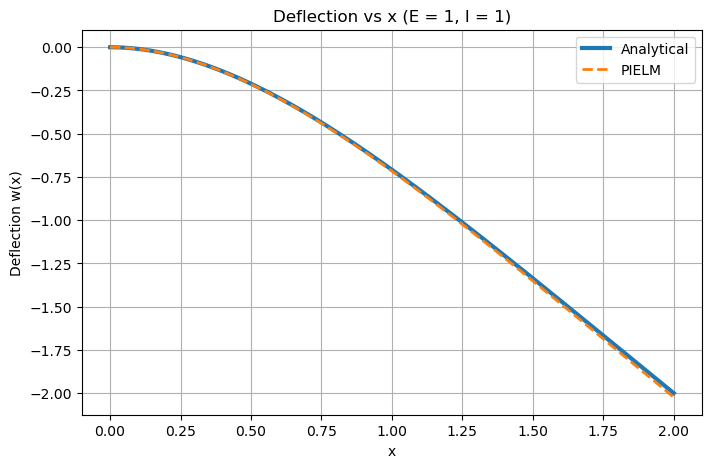

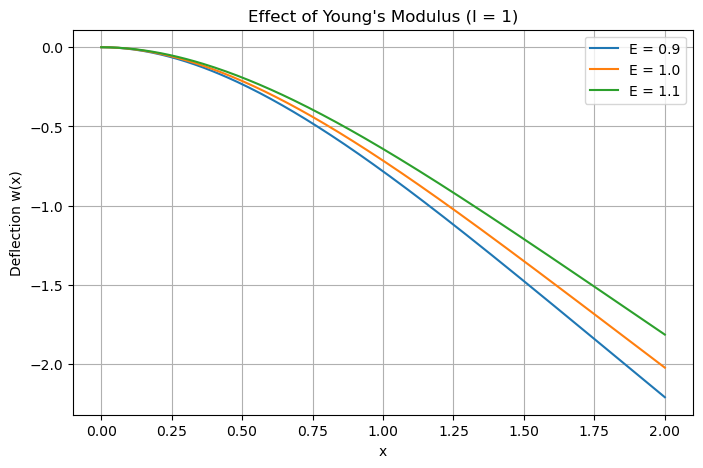

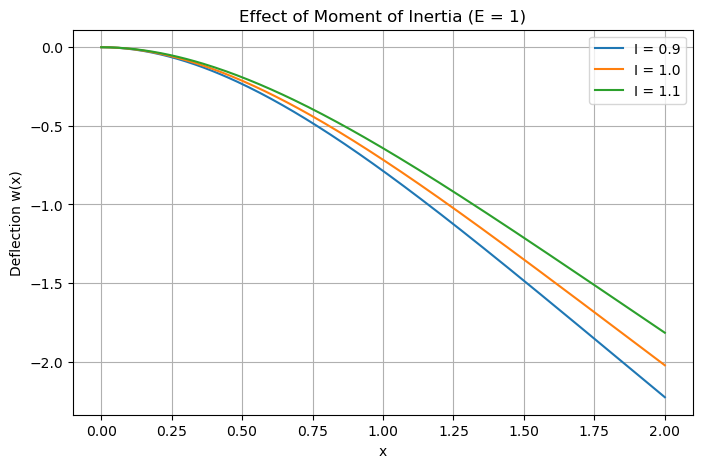

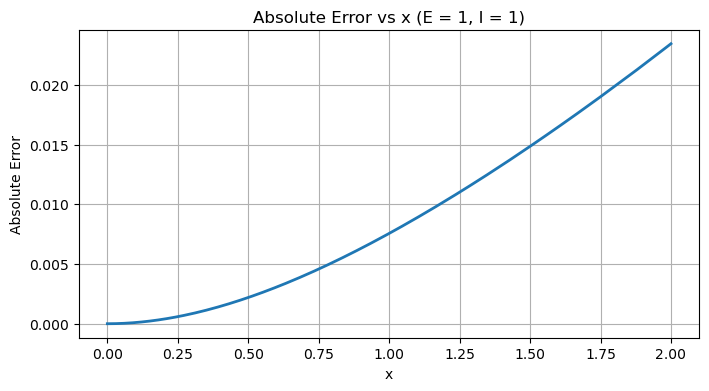

In [9]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION (PHYSICAL w)
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION (xbar, E~, I~)
# =============================================================================
def normalize(xei):
    x = xei[:, 0:1]
    E = xei[:, 1:2]
    I = xei[:, 2:3]
    xbar = x / L  # [0,1]
    Ehat = 2*(E - E_range[0])/(E_range[1]-E_range[0]) - 1
    Ihat = 2*(I - I_range[0])/(I_range[1]-I_range[0]) - 1
    return torch.cat([xbar, Ehat, Ihat], dim=1)

# =============================================================================
# DERIVATIVES wrt physical x (xei[:,0])
# =============================================================================
def derivative(u, xei, order):
    cur = u
    for _ in range(order):
        cur = autograd.grad(cur.sum(), xei, create_graph=True)[0][:, 0:1]
    return cur

# =============================================================================
# TRAIN (learn dimensionless wbar; recover physical w after)
# =============================================================================
def train_pielm_scaled(hidden_size=40, seed=0, lambda_reg=1.0, gauss_scale=0.5,
                       n_mc=4000, n_bc=200):
    torch.manual_seed(seed)

    # Random ELM params
    W = torch.randn(3, hidden_size) * 0.1
    b = torch.randn(hidden_size) * 0.1

    def activation(z):
        return torch.exp(-(z/gauss_scale)**2)

    # ----------------------------
    # Monte Carlo collocation points in physical domain
    # ----------------------------
    x = torch.rand(n_mc, 1) * L
    E = E_range[0] + torch.rand(n_mc, 1) * (E_range[1] - E_range[0])
    I = I_range[0] + torch.rand(n_mc, 1) * (I_range[1] - I_range[0])
    xei = torch.cat([x, E, I], dim=1).requires_grad_(True)

    # ----------------------------
    # BC-embedded trial for wbar:
    #   wbar(x) = xbar^2 * (H beta + beta0)
    # This enforces wbar(0)=0 and wbar'(0)=0 automatically.
    # ----------------------------
    xbar = xei[:, 0:1] / L
    Z = normalize(xei) @ W + b
    H = activation(Z)
    Phi = (xbar**2) * H                      # [n_mc, hidden]
    Phi_aug = torch.hstack([Phi, (xbar**2)]) # add beta0 term as xbar^2 * beta0

    # ----------------------------
    # PDE for dimensionless wbar:
    #   wbar''''(xbar) = 1
    #
    # Our derivatives are wrt physical x:
    #   d^4/dx^4 = (1/L^4) d^4/dxbar^4
    # So:
    #   wbar_xxxx_phys = 1/L^4
    #
    # Multiply both sides by L^4 for conditioning:
    #   L^4 * wbar_xxxx_phys = 1
    # ----------------------------
    Acols = []
    for j in range(hidden_size + 1):
        basis_j = Phi_aug[:, j:j+1]
        wbar_xxxx_phys = derivative(basis_j, xei, 4)
        Acols.append((L**4) * wbar_xxxx_phys)   # scale to target 1

    A_pde = torch.hstack(Acols)
    b_pde = torch.ones(A_pde.shape[0], 1)       # RHS = 1

    # ----------------------------
    # Boundary conditions at x=L for wbar:
    #   wbar''(1)=0, wbar'''(1)=0
    # Zeros are invariant to scaling, so we can enforce using physical derivatives too.
    # ----------------------------
    xL = torch.ones(n_bc, 1) * L
    Ebc = E_range[0] + torch.rand(n_bc, 1) * (E_range[1] - E_range[0])
    Ibc = I_range[0] + torch.rand(n_bc, 1) * (I_range[1] - I_range[0])
    xeiL = torch.cat([xL, Ebc, Ibc], dim=1).requires_grad_(True)

    xbarL = xeiL[:, 0:1] / L
    ZL = normalize(xeiL) @ W + b
    HL = activation(ZL)
    PhiL = (xbarL**2) * HL
    PhiL_aug = torch.hstack([PhiL, (xbarL**2)])

    BC2_cols, BC3_cols = [], []
    for j in range(hidden_size + 1):
        basisLj = PhiL_aug[:, j:j+1]
        wbar_xx_phys  = derivative(basisLj, xeiL, 2)
        wbar_xxx_phys = derivative(basisLj, xeiL, 3)
        BC2_cols.append(wbar_xx_phys)
        BC3_cols.append(wbar_xxx_phys)

    C = torch.vstack([torch.hstack(BC2_cols), torch.hstack(BC3_cols)])
    d = torch.zeros(C.shape[0], 1)

    # ----------------------------
    # KKT system (same structure)
    # ----------------------------
    A_T = A_pde.T
    C_T = C.T

    KKT_top = torch.hstack([A_T @ A_pde + lambda_reg * torch.eye(hidden_size + 1), C_T])
    KKT_bot = torch.hstack([C, torch.zeros((C.shape[0], C.shape[0]))])
    KKT = torch.vstack([KKT_top, KKT_bot])

    rhs = torch.vstack([A_T @ b_pde, d])

    sol = torch.linalg.solve(KKT, rhs)
    beta_aug = sol[:hidden_size + 1]
    beta = beta_aug[:hidden_size]
    beta0 = beta_aug[hidden_size:].item()

    # ----------------------------
    # Predict physical w(x,E,I):
    #   w = (Q L^4 / (E I)) * wbar
    # where wbar = xbar^2*(H beta + beta0)
    # ----------------------------
    def predict_w_phys(xei_query):
        x = xei_query[:, 0:1]
        E = xei_query[:, 1:2]
        I = xei_query[:, 2:3]
        xbar = x / L
        Hq = activation(normalize(xei_query) @ W + b)
        wbar = (xbar**2) * (Hq @ beta + beta0)  # dimensionless
        w_phys = (Q * (L**4) / (E * I)) * wbar  # physical
        return w_phys

    # For verification/debug: dimensionless predictor too
    def predict_wbar(xei_query):
        xbar = xei_query[:, 0:1] / L
        Hq = activation(normalize(xei_query) @ W + b)
        return (xbar**2) * (Hq @ beta + beta0)

    return predict_w_phys, predict_wbar, beta0

# =============================================================================
# VALIDATION (relative + RMSE + max abs) on random MC test points
# =============================================================================
def validate(predict_w_phys, n_test=5000):
    x = torch.rand(n_test, 1) * L
    E = E_range[0] + torch.rand(n_test, 1) * (E_range[1]-E_range[0])
    I = I_range[0] + torch.rand(n_test, 1) * (I_range[1]-I_range[0])
    xei = torch.cat([x, E, I], dim=1)

    w_pred = predict_w_phys(xei)
    w_exact = analytical_solution(x, E, I)

    rel = torch.norm(w_pred - w_exact) / torch.norm(w_exact)
    rmse = torch.sqrt(torch.mean((w_pred - w_exact)**2))
    max_abs = torch.max(torch.abs(w_pred - w_exact)).item()
    return rel.item(), rmse.item(), max_abs

# =============================================================================
# AUTO-TUNE (only hyperparameters; method unchanged)
# =============================================================================
best = {"rel": float("inf"), "cfg": None, "predict": None, "predict_wbar": None, "beta0": None}

hidden_list = [30, 40, 50]
seed_list   = [0, 1, 2]
lambda_list = [0.1, 0.5, 1.0, 2.0]
sigma_list  = [0.3, 0.5, 0.7]
mc_list     = [2000, 4000, 6000]

for h in hidden_list:
    for s in seed_list:
        for lam in lambda_list:
            for sig in sigma_list:
                for nmc in mc_list:
                    predict_w, predict_wbar, beta0 = train_pielm_scaled(
                        hidden_size=h, seed=s, lambda_reg=lam, gauss_scale=sig,
                        n_mc=nmc, n_bc=200
                    )
                    rel, rmse, max_abs = validate(predict_w, n_test=5000)

                    if rel < best["rel"]:
                        best["rel"] = rel
                        best["cfg"] = (h, s, lam, sig, nmc, rmse, max_abs)
                        best["predict"] = predict_w
                        best["predict_wbar"] = predict_wbar
                        best["beta0"] = beta0

print("\nBEST MODEL")
print("hidden, seed, lambda, sigma, n_mc, RMSE, MaxAbs =", best["cfg"])
print("Best Relative Error (%) =", best["rel"]*100)
print("beta0 (dimensionless, inside xbar^2*(...)) =", best["beta0"])

best_predict = best["predict"]
best_predict_wbar = best["predict_wbar"]

# =============================================================================
# PLOTS at E=1, I=1 (physical)
# =============================================================================
x_plot = torch.linspace(0, L, 200).reshape(-1, 1)
xei_plot = torch.cat([x_plot, torch.ones_like(x_plot), torch.ones_like(x_plot)], dim=1)

w_pred = best_predict(xei_plot).detach().numpy().flatten()
w_exact = analytical_solution(x_plot, 1.0, 1.0).numpy().flatten()

plt.figure(figsize=(9,5))
plt.plot(x_plot.numpy().flatten(), w_exact, label="Analytical", linewidth=3)
plt.plot(x_plot.numpy().flatten(), w_pred, "--", label="PIELM (scaled)", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Beam deflection (E=1, I=1) — scaled PIELM")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9,4))
plt.plot(x_plot.numpy().flatten(), np.abs(w_pred - w_exact), linewidth=2)
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.title("Absolute error (E=1, I=1)")
plt.grid(True)
plt.show()

# =============================================================================
# COMPREHENSIVE VERIFICATION
# =============================================================================
print("\n" + "="*59)
print("COMPREHENSIVE VERIFICATION")
print("="*59)

# BC check for physical w at E=I=1
xe0 = torch.tensor([[0.0, 1.0, 1.0]], dtype=torch.float32, requires_grad=True)
xeL = torch.tensor([[L,   1.0, 1.0]], dtype=torch.float32, requires_grad=True)

w0 = best_predict(xe0)
w0x = autograd.grad(w0.sum(), xe0, create_graph=True)[0][0,0]

wL = best_predict(xeL)
wL_xx  = derivative(wL, xeL, 2)[0,0]
wL_xxx = derivative(wL, xeL, 3)[0,0]

print("BCs (physical w) at E=1, I=1:")
print(f"  w(0)      = {w0.item(): .3e}  (target 0)")
print(f"  w'(0)     = {w0x.item(): .3e}  (target 0)")
print(f"  w''(L)    = {wL_xx.item(): .3e}  (target 0)")
print(f"  w'''(L)   = {wL_xxx.item(): .3e}  (target 0)")

# PDE residual check using wbar (should satisfy wbar'''' = 1)
print("\nPDE residual check on random points (wbar):")
for k in range(5):
    x = torch.rand(1,1)*L
    E = E_range[0] + torch.rand(1,1)*(E_range[1]-E_range[0])
    I = I_range[0] + torch.rand(1,1)*(I_range[1]-I_range[0])
    xei = torch.cat([x,E,I], dim=1).requires_grad_(True)

    wbar = best_predict_wbar(xei)
    wbar_xxxx_phys = derivative(wbar, xei, 4)
    residual = (L**4) * wbar_xxxx_phys - 1.0

    print(f"  sample {k+1}: x={x.item():.3f}, E={E.item():.3f}, I={I.item():.3f}, residual={residual.item(): .3e}")
    # =============================================================================
# ADDITIONAL PLOTS (NO CHANGE TO SOLVER)
# =============================================================================

# Common x grid
x_plot = torch.linspace(0, L, 200).reshape(-1, 1)

# -------------------------------------------------------------------------
# 1) Deflection vs x (E=1, I=1)
# -------------------------------------------------------------------------
xei_ref = torch.cat([
    x_plot,
    torch.ones_like(x_plot),
    torch.ones_like(x_plot)
], dim=1)

w_pred = best_predict(xei_ref).detach().numpy().flatten()
w_exact = analytical_solution(x_plot, 1.0, 1.0).numpy().flatten()

plt.figure(figsize=(8,5))
plt.plot(x_plot.numpy(), w_exact, label="Analytical", linewidth=3)
plt.plot(x_plot.numpy(), w_pred, "--", label="PIELM", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Deflection vs x (E = 1, I = 1)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------------------------------------------------
# 2) Effect of Young's Modulus E (I = 1)
# -------------------------------------------------------------------------
plt.figure(figsize=(8,5))
for E_val in [0.9, 1.0, 1.1]:
    xei_E = torch.cat([
        x_plot,
        torch.ones_like(x_plot) * E_val,
        torch.ones_like(x_plot)
    ], dim=1)
    wE = best_predict(xei_E).detach().numpy().flatten()
    plt.plot(x_plot.numpy(), wE, label=f"E = {E_val}")

plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Effect of Young's Modulus (I = 1)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------------------------------------------------
# 3) Effect of Moment of Inertia I (E = 1)
# -------------------------------------------------------------------------
plt.figure(figsize=(8,5))
for I_val in [0.9, 1.0, 1.1]:
    xei_I = torch.cat([
        x_plot,
        torch.ones_like(x_plot),
        torch.ones_like(x_plot) * I_val
    ], dim=1)
    wI = best_predict(xei_I).detach().numpy().flatten()
    plt.plot(x_plot.numpy(), wI, label=f"I = {I_val}")

plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Effect of Moment of Inertia (E = 1)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------------------------------------------------
# 4) Absolute Error vs x (E=1, I=1)
# -------------------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(x_plot.numpy(), np.abs(w_pred - w_exact), linewidth=2)
plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs x (E = 1, I = 1)")
plt.grid(True)
plt.show()



Training complete | beta0 = 0.16226482391357422

Computing mean & variance under uncertainty (E,I)...


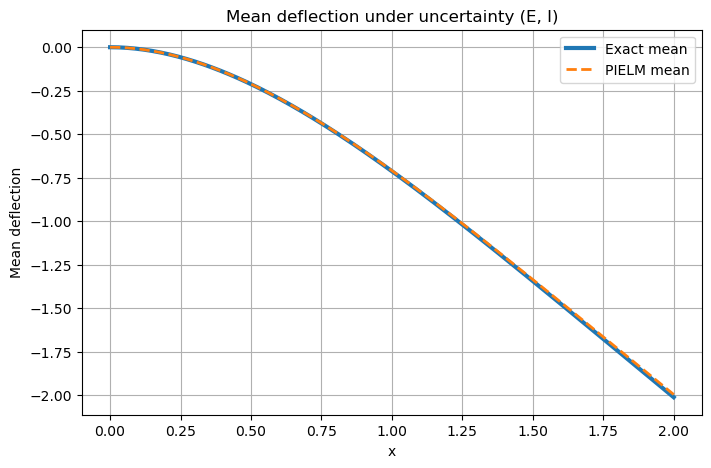

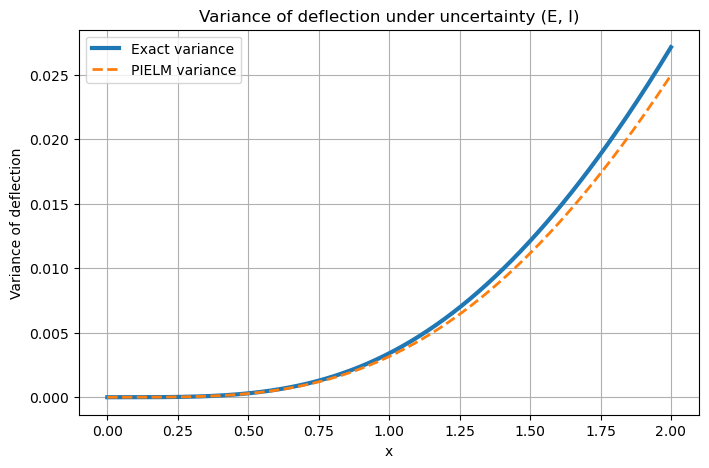


Computing probability density (bell curve) at a fixed location...

UNCERTAINTY STATISTICS (Bell Curve)
--------------------------------------------------
Location x*         = 2.0
Exact mean          = -2.011968
Exact std           = 0.164742
PIELM mean          = -1.996229
PIELM std           = 0.157955
Mean error (%)      = 0.78
Std error (%)       = 4.12


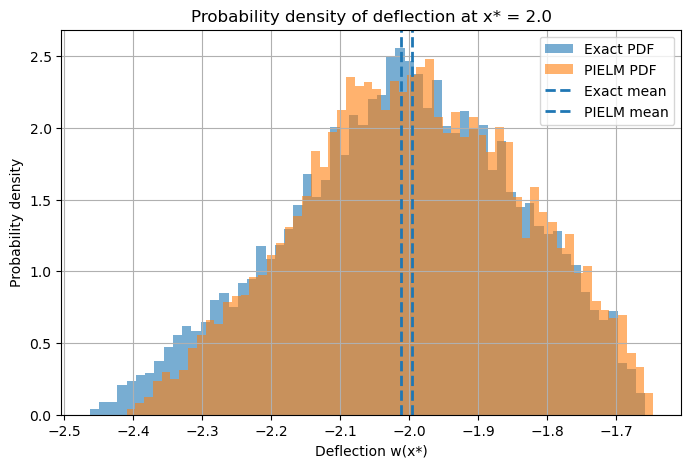

In [11]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    xbar = xei[:, 0:1] / L
    Ehat = 2*(xei[:, 1:2]-E_range[0])/(E_range[1]-E_range[0]) - 1
    Ihat = 2*(xei[:, 2:3]-I_range[0])/(I_range[1]-I_range[0]) - 1
    return torch.cat([xbar, Ehat, Ihat], dim=1)

# =============================================================================
# DERIVATIVES wrt x
# =============================================================================
def derivative(u, xei, order):
    cur = u
    for _ in range(order):
        cur = autograd.grad(cur.sum(), xei, create_graph=True)[0][:, 0:1]
    return cur

# =============================================================================
# TRAINING: MONTE CARLO PIELM (GAUSSIAN + KKT)
# =============================================================================
def train_pielm_scaled(
    hidden_size=40,
    seed=0,
    lambda_reg=1.0,
    gauss_scale=0.5,
    n_mc=4000,
    n_bc=200
):
    torch.manual_seed(seed)

    # Random ELM params
    W = torch.randn(3, hidden_size) * 0.1
    b = torch.randn(hidden_size) * 0.1

    def activation(z):
        return torch.exp(-(z/gauss_scale)**2)

    # ---------------- Monte Carlo collocation ----------------
    x = torch.rand(n_mc, 1) * L
    E = E_range[0] + torch.rand(n_mc, 1) * (E_range[1] - E_range[0])
    I = I_range[0] + torch.rand(n_mc, 1) * (I_range[1] - I_range[0])
    xei = torch.cat([x, E, I], dim=1).requires_grad_(True)

    # BC-embedded basis for wbar
    xbar = xei[:, 0:1] / L
    H = activation(normalize(xei) @ W + b)
    Phi = (xbar**2) * H
    Phi_aug = torch.hstack([Phi, xbar**2])  # adds beta0 basis

    # ---------------- PDE: L^4 * wbar_xxxx = 1 ----------------
    Acols = []
    for j in range(hidden_size + 1):
        w4 = derivative(Phi_aug[:, j:j+1], xei, 4)
        Acols.append((L**4) * w4)

    A_pde = torch.hstack(Acols)
    b_pde = torch.ones(A_pde.shape[0], 1)

    # ---------------- BC at x=L: wbar''=0, wbar'''=0 ----------------
    xL = torch.ones(n_bc, 1) * L
    Ebc = E_range[0] + torch.rand(n_bc, 1) * (E_range[1] - E_range[0])
    Ibc = I_range[0] + torch.rand(n_bc, 1) * (I_range[1] - I_range[0])
    xeiL = torch.cat([xL, Ebc, Ibc], dim=1).requires_grad_(True)

    xbarL = xeiL[:, 0:1] / L
    HL = activation(normalize(xeiL) @ W + b)
    PhiL = (xbarL**2) * HL
    PhiL_aug = torch.hstack([PhiL, xbarL**2])

    BC2, BC3 = [], []
    for j in range(hidden_size + 1):
        BC2.append(derivative(PhiL_aug[:, j:j+1], xeiL, 2))
        BC3.append(derivative(PhiL_aug[:, j:j+1], xeiL, 3))

    C = torch.vstack([torch.hstack(BC2), torch.hstack(BC3)])
    d = torch.zeros(C.shape[0], 1)

    # ---------------- KKT ----------------
    A_T = A_pde.T
    C_T = C.T

    KKT_top = torch.hstack([A_T @ A_pde + lambda_reg * torch.eye(hidden_size + 1), C_T])
    KKT_bot = torch.hstack([C, torch.zeros((C.shape[0], C.shape[0]))])
    KKT = torch.vstack([KKT_top, KKT_bot])

    rhs = torch.vstack([A_T @ b_pde, d])
    sol = torch.linalg.solve(KKT, rhs)

    beta_aug = sol[:hidden_size + 1]
    beta = beta_aug[:-1]
    beta0 = beta_aug[-1].item()

    # ---------------- Predictor (physical w) ----------------
    def predict(xei_q):
        xbarq = xei_q[:, 0:1] / L
        Hq = activation(normalize(xei_q) @ W + b)
        wbar = (xbarq**2) * (Hq @ beta + beta0)
        return (Q * L**4 / (xei_q[:, 1:2] * xei_q[:, 2:3])) * wbar

    return predict, beta0

# =============================================================================
# TRAIN MODEL
# =============================================================================
predict, beta0 = train_pielm_scaled()
print("Training complete | beta0 =", beta0)

# =============================================================================
# MEAN & VARIANCE UNDER UNCERTAINTY (E, I uncertain)
# =============================================================================
print("\nComputing mean & variance under uncertainty (E,I)...")

n_uq = 4000
x_plot = torch.linspace(0, L, 200).reshape(-1, 1)

E_uq = E_range[0] + torch.rand(n_uq, 1) * (E_range[1] - E_range[0])
I_uq = I_range[0] + torch.rand(n_uq, 1) * (I_range[1] - I_range[0])

w_exact_all = []
w_pred_all = []

for i in range(n_uq):
    Ei = E_uq[i].item()
    Ii = I_uq[i].item()

    xei = torch.cat([
        x_plot,
        torch.ones_like(x_plot) * Ei,
        torch.ones_like(x_plot) * Ii
    ], dim=1)

    w_exact_all.append(analytical_solution(x_plot, Ei, Ii))
    w_pred_all.append(predict(xei).detach())

w_exact_all = torch.stack(w_exact_all, dim=1)  # [nx, n_uq, 1]
w_pred_all  = torch.stack(w_pred_all,  dim=1)  # [nx, n_uq, 1]

mean_exact = torch.mean(w_exact_all, dim=1).squeeze(-1).detach().numpy()
var_exact  = torch.var(w_exact_all,  dim=1).squeeze(-1).detach().numpy()

mean_pred  = torch.mean(w_pred_all,  dim=1).squeeze(-1).detach().numpy()
var_pred   = torch.var(w_pred_all,   dim=1).squeeze(-1).detach().numpy()

x_np = x_plot.squeeze(-1).numpy()

# Mean plot
plt.figure(figsize=(8, 5))
plt.plot(x_np, mean_exact, label="Exact mean", linewidth=3)
plt.plot(x_np, mean_pred, "--", label="PIELM mean", linewidth=2)
plt.xlabel("x")
plt.ylabel("Mean deflection")
plt.title("Mean deflection under uncertainty (E, I)")
plt.legend()
plt.grid(True)
plt.show()

# Variance plot
plt.figure(figsize=(8, 5))
plt.plot(x_np, var_exact, label="Exact variance", linewidth=3)
plt.plot(x_np, var_pred, "--", label="PIELM variance", linewidth=2)
plt.xlabel("x")
plt.ylabel("Variance of deflection")
plt.title("Variance of deflection under uncertainty (E, I)")
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# PROBABILITY DENSITY (BELL CURVE) AT A FIXED LOCATION x*
# =============================================================================
print("\nComputing probability density (bell curve) at a fixed location...")

x_star = L  # tip location (change to L/2 for midspan)

n_pdf = 10000
x_pdf = torch.ones(n_pdf, 1) * x_star
E_pdf = E_range[0] + torch.rand(n_pdf, 1) * (E_range[1] - E_range[0])
I_pdf = I_range[0] + torch.rand(n_pdf, 1) * (I_range[1] - I_range[0])

xei_pdf = torch.cat([x_pdf, E_pdf, I_pdf], dim=1)

w_exact_pdf = analytical_solution(x_pdf, E_pdf, I_pdf).detach().numpy().flatten()
w_pred_pdf  = predict(xei_pdf).detach().numpy().flatten()

# Statistics for bell curve
mean_exact_pdf = np.mean(w_exact_pdf)
std_exact_pdf  = np.std(w_exact_pdf)

mean_pred_pdf = np.mean(w_pred_pdf)
std_pred_pdf  = np.std(w_pred_pdf)

print("\nUNCERTAINTY STATISTICS (Bell Curve)")
print("-"*50)
print(f"Location x*         = {x_star}")
print(f"Exact mean          = {mean_exact_pdf:.6f}")
print(f"Exact std           = {std_exact_pdf:.6f}")
print(f"PIELM mean          = {mean_pred_pdf:.6f}")
print(f"PIELM std           = {std_pred_pdf:.6f}")
print(f"Mean error (%)      = {abs(mean_pred_pdf-mean_exact_pdf)/abs(mean_exact_pdf)*100:.2f}")
print(f"Std error (%)       = {abs(std_pred_pdf-std_exact_pdf)/std_exact_pdf*100:.2f}")

# PDF plot (bell curves)
plt.figure(figsize=(8, 5))
plt.hist(w_exact_pdf, bins=60, density=True, alpha=0.6, label="Exact PDF")
plt.hist(w_pred_pdf,  bins=60, density=True, alpha=0.6, label="PIELM PDF")
plt.axvline(mean_exact_pdf, linestyle="--", linewidth=2, label="Exact mean")
plt.axvline(mean_pred_pdf,  linestyle="--", linewidth=2, label="PIELM mean")
plt.xlabel("Deflection w(x*)")
plt.ylabel("Probability density")
plt.title(f"Probability density of deflection at x* = {x_star}")
plt.legend()
plt.grid(True)
plt.show()
